# Parte 3 — Experimento A: DistilBERT
### Workshop: Clasificación de Emociones en Twitter

**Modelo:** `distilbert-base-uncased`  
**Pre-entrenamiento:** Wikipedia + BookCorpus (texto formal)  
**Tokenizador:** WordPiece

Este es nuestro **baseline**. Pre-entrenado en texto formal, sin conocimiento específico del lenguaje de Twitter.

**Prerequisito:** haber ejecutado `part-1-data.ipynb` y `part-2-pipeline.ipynb`

In [1]:
# Ejecutar primero part-2-pipeline.ipynb para tener todas las funciones disponibles
%run /teamspace/studios/this_studio/SI7011-DeepLearning/Lecture06/notebooks/excercise/tweeteval-part-2-pipeline.ipynb

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 3257
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1421
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 374
    })
})
compute_metrics OK
make_tokenized_dataset OK
full_evaluation OK
plot_training_curves OK
make_trainer OK

Pipeline lista. Puedes continuar con part-3-distilbert.ipynb


## Configuración del experimento

In [2]:
MODEL_CHECKPOINT = "distilbert-base-uncased"
HF_REPO          = "jezapataf/tweeteval-emotion-distilbert"  # <-- cambia esto
LR               = 2e-5

### 📝 TODO 3.1 — Tokenizar el dataset con DistilBERT

Usa `make_tokenized_dataset` con el tokenizador correcto y guarda el resultado en `ds_distilbert`.

In [3]:
# TODO 3.1 ── Tokenizar con DistilBERT
# ─────────────────────────────────────────────────────────────────────────────
tok_distilbert = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

ds_distilbert = make_tokenized_dataset(tok_distilbert)

print(ds_distilbert)


DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3257
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1421
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 374
    })
})


### 📝 TODO 3.2 — Cargar el modelo y contar parámetros

In [4]:
# TODO 3.2 ── Cargar DistilBERT para clasificación
# ─────────────────────────────────────────────────────────────────────────────
# Carga AutoModelForSequenceClassification con num_labels, id2label, label2id
# Imprime el número total de parámetros y los entrenables

# YOUR CODE HERE
model_distilbert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID
)

# Total de parámetros
total_params = sum(p.numel() for p in model_distilbert.parameters())

# Parámetros entrenables
trainable_params = sum(
    p.numel() for p in model_distilbert.parameters()
    if p.requires_grad
)

print(f"Total parámetros: {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parámetros: 66,956,548
Parámetros entrenables: 66,956,548


### 📝 TODO 3.3 — Entrenar y evaluar

Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,0.866559,0.754386,0.548412,0.724599
2,0.561617,0.622743,0.706186,0.767380
3,0.379967,0.650911,0.705683,0.754011
4,0.306792,0.607906,0.738473,0.794118
5,0.234506,0.620678,0.738295,0.794118


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


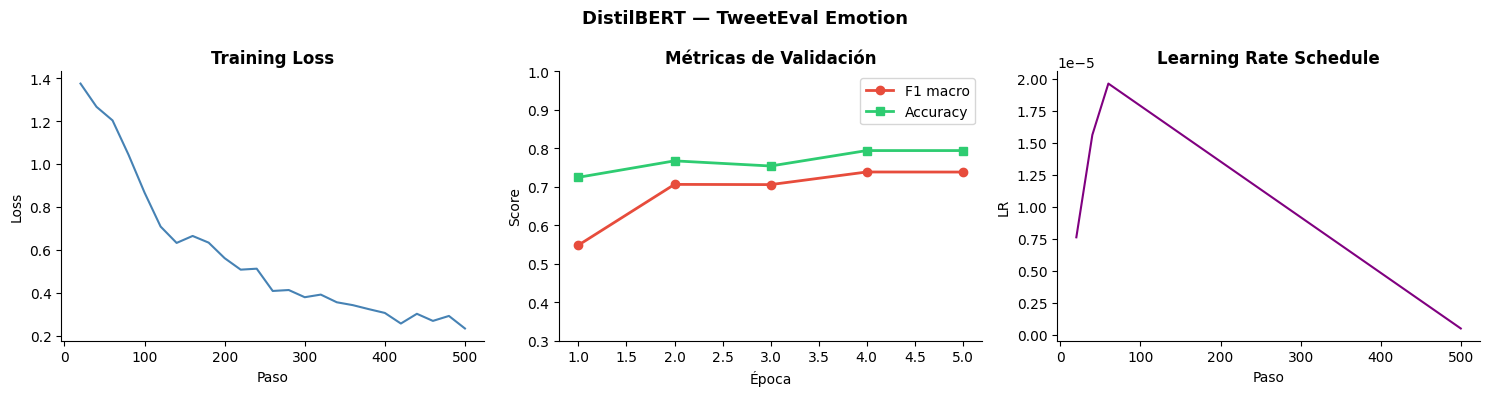


  Test — DistilBERT
              precision    recall  f1-score   support

       anger     0.8616    0.8369    0.8491       558
         joy     0.8082    0.8240    0.8160       358
    optimism     0.5983    0.5691    0.5833       123
     sadness     0.7859    0.8168    0.8010       382

    accuracy                         0.8051      1421
   macro avg     0.7635    0.7617    0.7624      1421
weighted avg     0.8050    0.8051    0.8048      1421



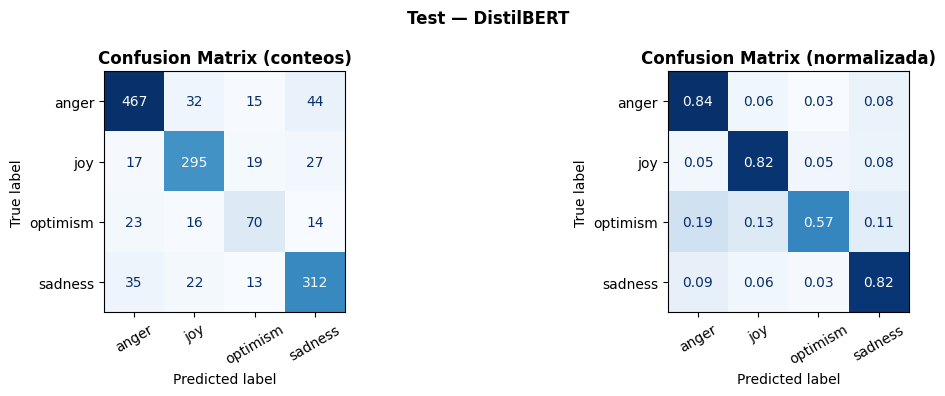

{'test_loss': 0.5646595358848572,
 'test_f1_macro': 0.7623738650224756,
 'test_accuracy': 0.8050668543279381,
 'test_runtime': 0.5588,
 'test_samples_per_second': 2542.854,
 'test_steps_per_second': 80.527}

In [5]:
# TODO 3.3 ── Entrenamiento de DistilBERT
# ─────────────────────────────────────────────────────────────────────────────
# 1. Crea el trainer con make_trainer()
#    Usa lr=LR y output_dir="./checkpoints/distilbert"
# 2. Llama trainer.train()
# 3. Llama plot_training_curves()
# 4. Llama full_evaluation() sobre ds_distilbert["test"]
#    Guarda el resultado en metrics_distilbert

# YOUR CODE HERE

trainer_distilbert = make_trainer(
    model=model_distilbert,
    tokenizer=tok_distilbert,
    tokenized_ds=ds_distilbert,
    output_dir="./checkpoints/distilbert",
    lr=LR
)

trainer_distilbert.train()

plot_training_curves(
    trainer_distilbert,
    title="DistilBERT — TweetEval Emotion"
)

metrics_distilbert = full_evaluation(
    trainer_distilbert,
    ds_distilbert["test"],
    model_name="DistilBERT"
)

metrics_distilbert

## Push to Hub

In [6]:
# Requiere: huggingface-cli login  (o haber cargado el token con python-dotenv)
trainer_distilbert.model.push_to_hub(HF_REPO)
tok_distilbert.push_to_hub(HF_REPO)

print(f"Modelo publicado en: https://huggingface.co/{HF_REPO}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


Modelo publicado en: https://huggingface.co/jezapataf/tweeteval-emotion-distilbert
